**3. UGV Navigation in Dynamic Obstacles Using Replanning**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import math
import time

In [2]:
GRID_SIZE = 70

START = (0, 0)
GOAL = (69, 69)

print("Grid size:", GRID_SIZE, "x", GRID_SIZE)
print("Start:", START)
print("Goal:", GOAL)

Grid size: 70 x 70
Start: (0, 0)
Goal: (69, 69)


In [3]:
MOVEMENTS = [
    (-1, 0, 1),
    (1, 0, 1),
    (0, -1, 1),
    (0, 1, 1),

    (-1, -1, math.sqrt(2)),
    (-1, 1, math.sqrt(2)),
    (1, -1, math.sqrt(2)),
    (1, 1, math.sqrt(2))
]

In [4]:
def heuristic(node, goal):

    x1, y1 = node
    x2, y2 = goal

    return math.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

In [5]:
def generate_dynamic_environment(
    grid_size,
    initial_density=0.10,
    dynamic_density=0.03,
    seed=42
):

    np.random.seed(seed)

    # Initially known obstacles
    initial_grid = (
        np.random.random(
            (grid_size, grid_size)
        ) < initial_density
    )

    # Dynamic obstacles that may appear later
    dynamic_grid = (
        np.random.random(
            (grid_size, grid_size)
        ) < dynamic_density
    )

    # Keep start and goal free
    initial_grid[START] = False
    initial_grid[GOAL] = False

    dynamic_grid[START] = False
    dynamic_grid[GOAL] = False

    return initial_grid, dynamic_grid

In [6]:
def a_star(grid, start, goal):

    rows, cols = grid.shape

    open_list = []

    g_cost = {
        start: 0
    }

    parent = {
        start: None
    }

    heapq.heappush(
        open_list,
        (heuristic(start, goal), start)
    )

    expanded_nodes = 0

    while open_list:

        current_f, current = heapq.heappop(
            open_list
        )

        expanded_nodes += 1

        if current == goal:

            path = []

            node = goal

            while node is not None:

                path.append(node)

                node = parent[node]

            path.reverse()

            return path, expanded_nodes

        x, y = current

        for dx, dy, movement_cost in MOVEMENTS:

            nx = x + dx
            ny = y + dy

            if nx < 0 or nx >= rows:
                continue

            if ny < 0 or ny >= cols:
                continue

            if grid[nx, ny]:
                continue

            neighbour = (nx, ny)

            new_cost = (
                g_cost[current] +
                movement_cost
            )

            if (
                neighbour not in g_cost
                or new_cost < g_cost[neighbour]
            ):

                g_cost[neighbour] = new_cost
                parent[neighbour] = current

                f_cost = (
                    new_cost +
                    heuristic(neighbour, goal)
                )

                heapq.heappush(
                    open_list,
                    (f_cost, neighbour)
                )

    return None, expanded_nodes

In [7]:
def dynamic_ugv_navigation(
    initial_grid,
    dynamic_grid,
    start,
    goal,
    detection_range=2
):

    # What the UGV currently knows
    known_grid = initial_grid.copy()

    current = start

    complete_path = [start]

    total_distance = 0
    total_expanded = 0
    replans = 0

    while current != goal:

        # Discover dynamic obstacles near the UGV
        cx, cy = current

        for x in range(
            max(0, cx - detection_range),
            min(GRID_SIZE, cx + detection_range + 1)
        ):

            for y in range(
                max(0, cy - detection_range),
                min(GRID_SIZE, cy + detection_range + 1)
            ):

                if dynamic_grid[x, y]:

                    known_grid[x, y] = True

        # Plan from current position
        path, expanded = a_star(
            known_grid,
            current,
            goal
        )

        total_expanded += expanded
        replans += 1

        if path is None:
            return {
                "success": False,
                "path": complete_path,
                "distance": total_distance,
                "replans": replans,
                "nodes_expanded": total_expanded
            }

        # Move one step at a time
        moved = False

        for next_position in path[1:]:

            # Check whether a newly discovered obstacle
            # blocks the next movement
            if dynamic_grid[next_position]:

                known_grid[next_position] = True

                replans += 1

                break

            # Move UGV
            x1, y1 = current
            x2, y2 = next_position

            step_distance = math.sqrt(
                (x2 - x1) ** 2 +
                (y2 - y1) ** 2
            )

            total_distance += step_distance

            current = next_position

            complete_path.append(current)

            moved = True

            if current == goal:
                break

            # Detect obstacles again
            break

        if current == goal:
            break

        if not moved:
            continue

    return {
        "success": current == goal,
        "path": complete_path,
        "distance": total_distance,
        "replans": replans,
        "nodes_expanded": total_expanded
    }

In [8]:
initial_grid, dynamic_grid = generate_dynamic_environment(
    GRID_SIZE,
    initial_density=0.10,
    dynamic_density=0.03,
    seed=42
)

print("Environment generated.")
print("Initial obstacles:",
      np.sum(initial_grid))

print("Hidden dynamic obstacles:",
      np.sum(dynamic_grid))

Environment generated.
Initial obstacles: 519
Hidden dynamic obstacles: 134


In [9]:
start_time = time.perf_counter()

result = dynamic_ugv_navigation(
    initial_grid,
    dynamic_grid,
    START,
    GOAL
)

execution_time = time.perf_counter() - start_time

print("Navigation completed.")

print("Success:", result["success"])
print("Total distance:",
      round(result["distance"], 2),
      "km")

print("Number of replans:",
      result["replans"])

print("Nodes expanded:",
      result["nodes_expanded"])

print("Execution time:",
      round(execution_time, 6),
      "seconds")

Navigation completed.
Success: True
Total distance: 99.34 km
Number of replans: 72
Nodes expanded: 10486
Execution time: 0.078286 seconds


In [10]:
def plot_dynamic_path(
    initial_grid,
    dynamic_grid,
    path,
    start,
    goal
):

    plt.figure(figsize=(9, 9))

    plt.imshow(
        initial_grid,
        cmap="gray_r",
        origin="lower"
    )

    # Show hidden dynamic obstacles
    dynamic_positions = np.argwhere(dynamic_grid)

    if len(dynamic_positions) > 0:

        plt.scatter(
            dynamic_positions[:, 1],
            dynamic_positions[:, 0],
            marker="x",
            s=15,
            label="Dynamic obstacles"
        )

    if path:

        x = [p[1] for p in path]
        y = [p[0] for p in path]

        plt.plot(
            x,
            y,
            linewidth=2,
            label="UGV path"
        )

    plt.scatter(
        start[1],
        start[0],
        marker="o",
        s=100,
        label="Start"
    )

    plt.scatter(
        goal[1],
        goal[0],
        marker="*",
        s=150,
        label="Goal"
    )

    plt.xlabel("X coordinate (km)")
    plt.ylabel("Y coordinate (km)")
    plt.title("UGV Navigation in Dynamic Environment")

    plt.legend()
    plt.show()

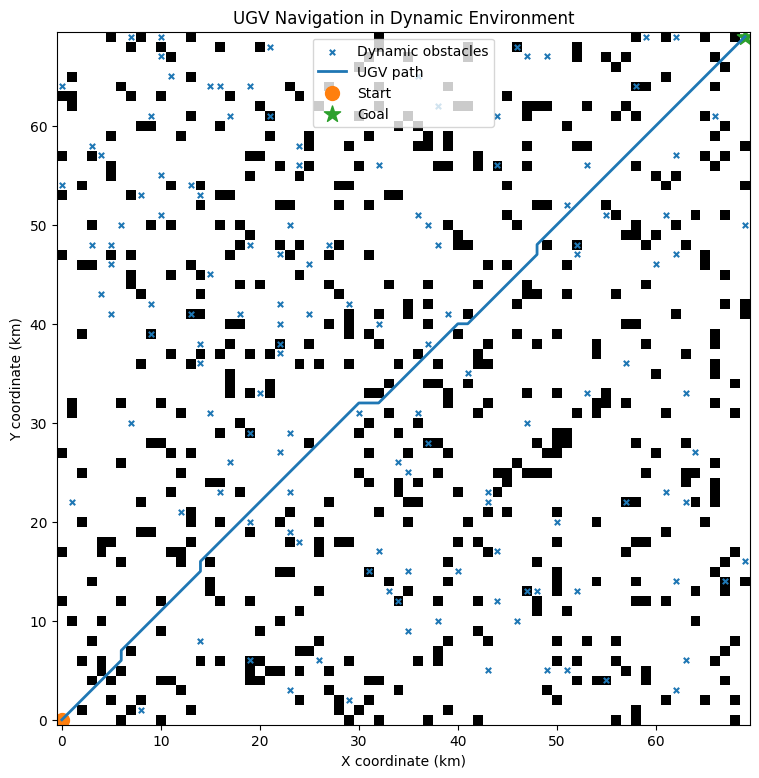

In [11]:
plot_dynamic_path(
    initial_grid,
    dynamic_grid,
    result["path"],
    START,
    GOAL
)